# Debugging

In [1]:
import pandas as pd
import geopandas as gpd
import shapely
import numpy as np
import json
import os
from functools import partial
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

import nomad.io.base as loader
import nomad.stop_detection.utils as utils
import nomad.stop_detection.lachesis as LACHESIS
import nomad.stop_detection.sequential as SEQUENTIAL
import nomad.stop_detection.dbscan as TADBSCAN
import nomad.stop_detection.grid_based as GRID_BASED # for oracle visits
import nomad.stop_detection.postprocessing as pp

import nomad.visit_attribution.visit_attribution as visits
import nomad.filters as filters
import nomad.city_gen as cg

from nomad.map_utils import blocks_to_mercator_gdf
from nomad.contact_estimation import compute_stop_detection_metrics
from nomad.stop_detection.viz import plot_stops_barcode, plot_time_barcode, plot_stops, plot_pings, _plot_base_geometry, plot_circles

In [2]:
with open('config_beta_5.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

In [3]:
poi_table = gpd.read_parquet(config["buildings_file"]).rename(columns={"id":"location"})
sparse_df = loader.from_file(config["output_files"]["sparse_path"], format="parquet")
diaries_df = loader.from_file(config["output_files"]["diaries_path"], format="parquet").rename(
    columns={"identifier":"user_id"})

In [4]:
diaries_df

,datetime,timestamp,duration,location,user_id,x,y,tz_offset
0,2024-06-01 00:00:12,1717214412,90,w-x17-y10,admiring_amazing_gates,-4265429.0,4393133.5,-14400
1,2024-06-01 01:30:12,1717219812,1,None,admiring_amazing_gates,NaN,NaN,-14400
2,2024-06-01 01:31:24,1717219884,88,r-x19-y11,admiring_amazing_gates,-4265414.0,4393148.5,-14400
3,2024-06-01 00:00:12,1717214412,90,w-x17-y10,admiring_amazing_lumiere,-4265429.0,4393133.5,-14400
4,2024-06-01 01:30:12,1717219812,1,None,admiring_amazing_lumiere,NaN,NaN,-14400
...,...,...,...,...,...,...,...,...
5995,2024-06-01 01:30:12,1717219812,1,None,youthful_zealous_austin,NaN,NaN,-14400
5996,2024-06-01 01:31:24,1717219884,88,r-x19-y11,youthful_zealous_austin,-4265414.0,4393148.5,-14400
5997,2024-06-01 00:00:12,1717214412,90,w-x17-y10,youthful_zealous_euler,-4265429.0,4393133.5,-14400
5998,2024-06-01 01:30:12,1717219812,1,None,youthful_zealous_euler,NaN,NaN,-14400


In [5]:
sparse_df = sparse_df[sparse_df['user_id'] == 'agitated_angry_colden']

In [6]:
sparse_df.drop(columns=['datetime'], inplace=True)

In [7]:
diaries_df = diaries_df[diaries_df['user_id'] == 'agitated_angry_colden']

In [8]:
diaries_df

,datetime,timestamp,duration,location,user_id,x,y,tz_offset
381,2024-06-01 00:00:12,1717214412,90,w-x17-y10,agitated_angry_colden,-4265429.0,4393133.5,-14400
382,2024-06-01 01:30:12,1717219812,0,None,agitated_angry_colden,NaN,NaN,-14400
383,2024-06-01 01:31:00,1717219860,89,r-x19-y11,agitated_angry_colden,-4265414.0,4393148.5,-14400


In [9]:
# Parameters
delta_roam = 32
dt_max=45
dur_min=5

sequential_stops = SEQUENTIAL.detect_stops(
    data=sparse_df,
    delta_roam=delta_roam,
    dt_max=dt_max,
    # dur_min=dur_min,
    method='centroid',
    complete_output=False,
    traj_cols={'x': 'x', 'y': 'y', 'timestamp': 'timestamp'}
)

In [10]:
sequential_stops

,cluster,x,y,timestamp,duration,user_id
0,0,-4.265436e+06,4.393144e+06,1717214485,97,agitated_angry_colden
1,1,-4.265403e+06,4.393155e+06,1717221085,63,agitated_angry_colden


In [11]:
labels = SEQUENTIAL.detect_stop_labels(
    data=sparse_df,
    delta_roam=delta_roam,
    dt_max=dt_max, 
    dur_min=dur_min,
    method='sliding',
    traj_cols={'x': 'x', 'y': 'y', 'timestamp': 'timestamp'}
)

sparse_df['cluster'] = labels

In [12]:
sparse_df["location"] = visits.point_in_polygon(
    data=sparse_df, 
    poi_table=poi_table, 
    data_crs='EPSG:3857',
    max_distance=10, 
    location_id='location', 
    method='majority',
    x='x', 
    y='y'
)

In [13]:
sparse_df

,x,y,timestamp,user_id,ha,tz_offset,cluster,location
4436,-4.265442e+06,4.393130e+06,1717214485,agitated_angry_colden,15.0,-14400,0,w-x17-y10
4437,-4.265432e+06,4.393154e+06,1717215080,agitated_angry_colden,15.0,-14400,0,w-x17-y10
4438,-4.265429e+06,4.393131e+06,1717215385,agitated_angry_colden,15.0,-14400,0,w-x17-y10
4439,-4.265457e+06,4.393132e+06,1717215506,agitated_angry_colden,15.0,-14400,0,w-x17-y10
4440,-4.265466e+06,4.393137e+06,1717215633,agitated_angry_colden,15.0,-14400,0,w-x17-y10
4441,-4.265460e+06,4.393155e+06,1717215755,agitated_angry_colden,15.0,-14400,0,w-x17-y10
4442,-4.265437e+06,4.393129e+06,1717216632,agitated_angry_colden,15.0,-14400,0,w-x17-y10
4443,-4.265429e+06,4.393147e+06,1717217063,agitated_angry_colden,15.0,-14400,0,w-x17-y10
4444,-4.265444e+06,4.393157e+06,1717217996,agitated_angry_colden,15.0,-14400,0,w-x17-y10
4445,-4.265437e+06,4.393142e+06,1717218066,agitated_angry_colden,15.0,-14400,0,w-x17-y10


In [14]:
summarize_stops_with_loc = partial(
    utils.summarize_stop,
    x='x',
    y='y',
    keep_col_names=False,
    passthrough_cols=['location'],
    complete_output=False)

stops = sparse_df[sparse_df.cluster!=-1].groupby('cluster', as_index=False).apply(
            summarize_stops_with_loc, include_groups=False)

In [15]:
stops

,cluster,x,y,start_timestamp,duration,location
0,0,-4.265437e+06,4.393142e+06,1717214485,60,w-x17-y10
1,1,-4.265427e+06,4.393157e+06,1717218453,30,w-x17-y10
2,2,-4.265403e+06,4.393155e+06,1717221150,62,r-x19-y11


In [16]:
diaries_df

,datetime,timestamp,duration,location,user_id,x,y,tz_offset
381,2024-06-01 00:00:12,1717214412,90,w-x17-y10,agitated_angry_colden,-4265429.0,4393133.5,-14400
382,2024-06-01 01:30:12,1717219812,0,None,agitated_angry_colden,NaN,NaN,-14400
383,2024-06-01 01:31:00,1717219860,89,r-x19-y11,agitated_angry_colden,-4265414.0,4393148.5,-14400


In [17]:
metrics = compute_stop_detection_metrics(
            stops=stops,
            truth=diaries_df,
            user_id='infallible_meninsky',
            algorithm='sequential',
            traj_cols={'location_id': 'location'},
            timestamp='timestamp'
        )

/Users/andresmondragon/nomad/nomad/io/base.py:129: UserWarning: Trajectory column 'timestamp' specified for 'timestamp' not found in DataFrame.
  warnings.warn(f"Trajectory column '{value}' specified for '{key}' not found in DataFrame.")


In [18]:
metrics

{'precision': np.float64(0.9473684210526315),
 'recall': np.float64(0.8044692737430168),
 'f1': np.float64(0.8700906344410877),
 'user_id': 'infallible_meninsky',
 'algorithm': 'sequential'}

In [19]:
labels

4436    0
4437    0
4438    0
4439    0
4440    0
4441    0
4442    0
4443    0
4444    0
4445    0
4446    0
4447    1
4448    1
4449    1
4450    1
4451    1
4452    1
4453    1
4454    1
4455   -1
4456    2
4457    2
4458    2
4459    2
4460    2
4461    2
4462    2
Name: cluster, dtype: int64

[]

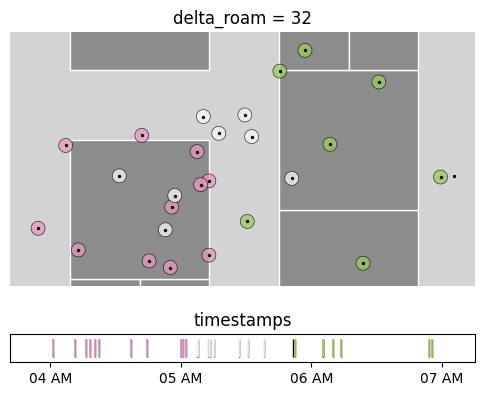

In [22]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,4.5),
                                         gridspec_kw={'height_ratios':[10,1]})
# Plot colored pings
ax_map.set_title("delta_roam = 32")
plot_circles(sparse_df, ax=ax_map, radius=1.5, color='cluster', cmap='PiYG', base_geometry=poi_table, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
plot_pings(sparse_df, ax=ax_map, s=2, color='black')
plot_time_barcode(sparse_df['timestamp'], ax=ax_barcode, set_xlim=True)
plot_time_barcode(sparse_df, color='cluster', ax=ax_barcode, cmap='PiYG', set_xlim=False, lw=1.3)

#plot_stops_barcode(diaries_df.dropna(), ax=ax_barcode, stop_alpha=0.6, cmap='inferno_r', set_xlim=False, timestamp='timestamp')

ax_barcode.set_title("timestamps")

plt.plot()

[]

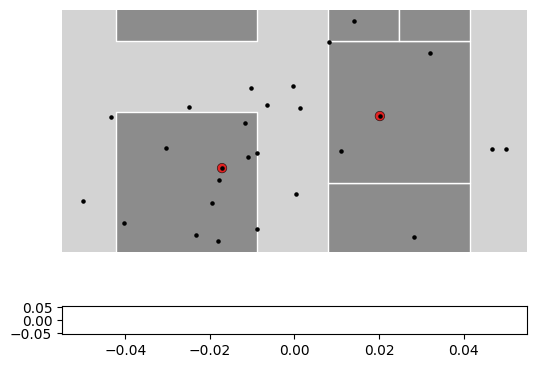

In [20]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,4.5),
                                         gridspec_kw={'height_ratios':[10,1]})


# Plot colored pings
plot_circles(sequential_stops, ax=ax_map, radius=1, color='red', cmap='inferno_r', base_geometry=poi_table, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
plot_pings(sparse_df, ax=ax_map, s=5, color='black')

plt.plot()